In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from gensim.models import Word2Vec, KeyedVectors
import gensim.downloader as api

plt.style.use('ggplot')

## 1. O Corpus e o treinamento do Word2Vec

Para entender como a rede neural aprende as representações, começaremos com um corpus de "brinquedo". Em cenários reais, utilizaríamos milhões de sentenças (como Wikipédia ou bases de notícias).  
  
O algoritmo Word2Vec possui duas arquiteturas principais que podemos configurar.
* CBOW (Continuous Bag of Words): Tenta prever a palavra alvo a partir do contexto (palavras vizinhas). É mais rápido e tem melhor representação para palavras frequentes.
* Skip-gram: Tenta prever o contexto a partir da palavra-alvo. É mais lento, mas funciona muito bem com bases de dados pequenas e representa melhoor palavras raras.
  
Principais hiperparâmetros:
* vector_size: A dimensionalidade dos vetores.
* window: A distância máxima entre a palavra atual e a palavra prevista na sentença.
* min_count: Ignora todas as palavras com frequência total inferior a esta.
* sg: O algoritmo de treinamento. 1 para skip-gram; do contrário, 0 para CBOW.

In [2]:
sentences = [
        ['gato', 'come', 'peixe'],
        ['cachorro', 'come', 'carne'],
        ['gato', 'e', 'cachorro', 'sao', 'animais'],
        ['peixe', 'vive', 'na', 'agua'],
        ['cachorro', 'late'],
        ['gato', 'mia'],
        ['leao', 'come', 'carne'],
        ['leao', 'e', 'um', 'animal', 'selvagem'],
        ['peixe', 'nada', 'na', 'agua' ]
]

model = Word2Vec(
        sentences=sentences,
        vector_size=20,
        window=2,
        min_count=1,
        sg=0,
        epochs=200
)

print('Vocabulário aprendido:', list(model.wv.index_to_key))

Vocabulário aprendido: ['cachorro', 'peixe', 'come', 'gato', 'leao', 'agua', 'na', 'e', 'carne', 'nada', 'selvagem', 'animal', 'um', 'mia', 'late', 'vive', 'animais', 'sao']


## 2. Acesso a vetores e propriedades do modelo

Uma vez treinado, os vetores ficam armazenados no objeto model.wv (word vectors). Este objeto é do tipo KeyedVectors e é otimizado para buscar rápidas.

In [3]:
vetor_gato = model.wv['gato']
print('Dimensão do vetor:', vetor_gato.shape)
print('Vetor de gato:\n', vetor_gato)

Dimensão do vetor: (20,)
Vetor de gato:
 [-0.00840339  0.00164755 -0.0204895  -0.03837592 -0.0073668   0.01291641
 -0.00305661  0.0287989  -0.0144895   0.0116235   0.0290909   0.04076406
 -0.00804086 -0.04687313  0.02164288  0.00329518  0.03922033 -0.00363401
 -0.01423957 -0.04395481]


#### Observando os token similares a gato

In [4]:
model.wv.most_similar('gato')

[('vive', 0.3799540102481842),
 ('selvagem', 0.2711317241191864),
 ('mia', 0.2701014578342438),
 ('come', 0.2372838407754898),
 ('sao', 0.21906708180904388),
 ('na', 0.20311741530895233),
 ('late', 0.1997944861650467),
 ('animal', 0.16473177075386047),
 ('peixe', 0.16192173957824707),
 ('nada', 0.10052548348903656)]

## 3. Explorando o espaço semântico

Como o modelo mapeou as palavras para um escopo vetorial, podemos usar a Similaridade de Cosseno para encontrar a distância angular entre dois vetores. Quanto mais próximo de 1, mais similares são os contextos em que as palavras aparecem.

In [5]:
# Calculando a similaridade de cosseno diretamente entre duas palavras
similaridade_gato_cachorro = model.wv.similarity('gato', 'cachorro')
similaridade_gato_peixe = model.wv.similarity('gato', 'peixe')

print(f'Similaridade (gato, cachorro): {similaridade_gato_cachorro:.4f}')
print(f'Similaridade (gato, peixe): {similaridade_gato_peixe:.4f}\n')

# Encontrando as N palavras mais similares no espaço vetorial
print("Palavras mais similares a 'come':")
for palavra, score in model.wv.most_similar('come', topn=3):
        print(f' - {palavra} ({score:.4f})')

# ODD-ONE-OUT: Qual palavra não pertence ao grupo?
print("\nPalavra intrusa no grupo ['gato', 'cachorro', 'carne']: ",
      model.wv.doesnt_match(['gato', 'cachorro', 'carne']))

Similaridade (gato, cachorro): 0.0942
Similaridade (gato, peixe): 0.1619

Palavras mais similares a 'come':
 - vive (0.3923)
 - gato (0.2373)
 - selvagem (0.2097)

Palavra intrusa no grupo ['gato', 'cachorro', 'carne']:  carne


## 4. Álgebra vetorial

In [6]:
# Tentando uma analogia no nosso corpus minúsculo:
# Se cachorro está para carne, assim como peixe está para o que?
# Equação: X = carne - cachorro + peixe

result = model.wv.most_similar(positive=['carne', 'peixe'], negative=['cachorro'], topn=5)

for palavra, score in result:
        print(f'carne - cachorro + peixe = {palavra:8} | {score:.2f}')

carne - cachorro + peixe = selvagem | 0.30
carne - cachorro + peixe = late     | 0.28
carne - cachorro + peixe = come     | 0.15
carne - cachorro + peixe = nada     | 0.13
carne - cachorro + peixe = na       | 0.10


In [7]:
# 1. Salvando apenas os vetores
model.wv.save('meus_vetores.kv')
wv_carregado = KeyedVectors.load('meus_vetores.kv')
print('Vetor recuperado do disco com sucesso.')

# 2. Salvando o modelo completo
model.save('meu_word2vec.model')

Vetor recuperado do disco com sucesso.


## 6. Modelos pré-treinados

In [8]:
# Mostrando os modelos disponíveis
print('Alguns modelos disponíveis para download:')
info = api.info()
for model_name in list(info['models'].keys())[:5]:
        print(f' - {model_name}')

# Carregando um modelo de demosntração rápido
print("\nBaixando/Carregando modelo 'glove-twitter-25...")
glove_model = api.load('glove-twitter-25')

print('\nSimilaridade entre computer e programming no Glove:',
      glove_model.similarity('computer', 'programming'))

print('\nAnalogia no Glove: King - Man + Women=')
for p, s in glove_model.most_similar(positive=['king', 'woman'], negative=['man'], topn=3):
        print(f' - {p} ({s:.4f})')

Alguns modelos disponíveis para download:
 - fasttext-wiki-news-subwords-300
 - conceptnet-numberbatch-17-06-300
 - word2vec-ruscorpora-300
 - word2vec-google-news-300
 - glove-wiki-gigaword-50

Baixando/Carregando modelo 'glove-twitter-25...
[==================================================] 100.0% 104.8/104.8MB downloaded

Similaridade entre computer e programming no Glove: 0.70801824

Analogia no Glove: King - Man + Women=
 - meets (0.8842)
 - prince (0.8322)
 - queen (0.8257)


## 7. Visualização

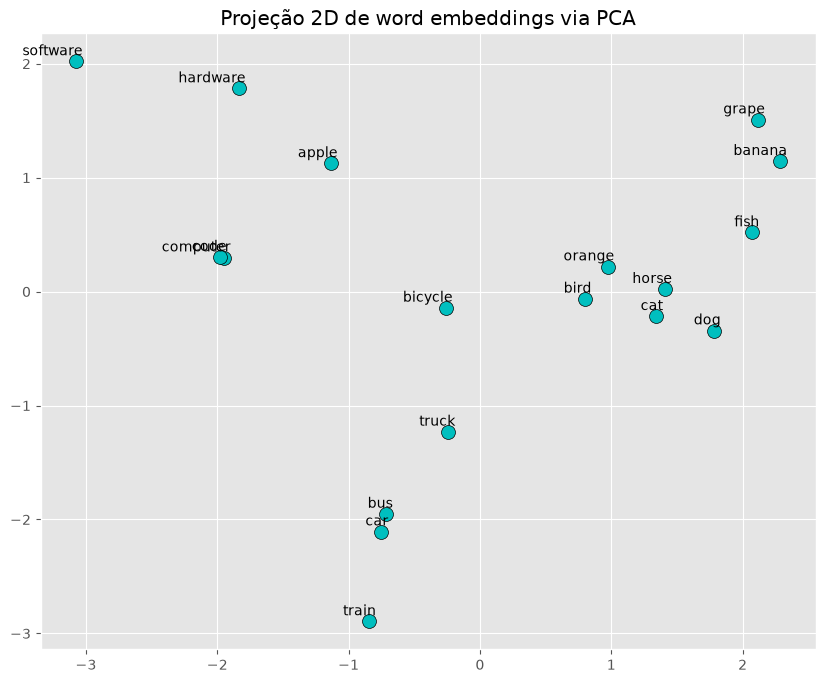

In [9]:
# Selecionando um subconjunto de palavras do modelo Glove para visualizar
palavras_para_plotar = [
    'car', 'bus', 'truck', 'bicycle', 'train',
    'apple', 'banana', 'orange', 'grape',
    'dog', 'cat', 'bird', 'fish', 'horse',
    'computer', 'software', 'hardware', 'code'
]

# Extraindo os vetores dessas palavras
vetores = np.array([glove_model[word] for word in palavras_para_plotar])

# Reduzindo a dimensionalidade de 25D para 2D com PCA
pca = PCA(n_components=2)
vetores_2d = pca.fit_transform(vetores)

# Plotando o gráfico de dispersão (Scatter plot)
plt.figure(figsize=(10,8))
plt.scatter(vetores_2d[:, 0], vetores_2d[:, 1], edgecolors='k', c='c', s=100)

# Adicionando os rótulos aos pontos
for i, palavra in enumerate(palavras_para_plotar):
        plt.annotate(palavra,
                xy=(vetores_2d[i,0], vetores_2d[i, 1]),
                xytext=(5,2),
                textcoords='offset points',
                ha='right',
                va='bottom')

plt.title('Projeção 2D de word embeddings via PCA')
plt.grid(True)
plt.show()